## Forward Propagation and Backpropagation using TensorFlow/Keras

In [11]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [12]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [13]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [14]:
def train_model(learning_rate=0.001, epochs=10):

    # --------------------------
    # Forward Propagation Model
    # --------------------------
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    # --------------------------
    # Compile Model
    # --------------------------
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # --------------------------
    # Training
    # Forward + Backpropagation
    # --------------------------
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    # --------------------------
    # Evaluate Model
    # --------------------------
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    print("\nLearning Rate :", learning_rate)
    print("Epochs        :", epochs)
    print("Test Accuracy :", round(test_accuracy,4))
    print("Test Loss     :", round(test_loss,4))

    return history, test_accuracy


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0976 - loss: 13.8896 - val_accuracy: 0.1025 - val_loss: 2.3381
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1001 - loss: 2.3104 - val_accuracy: 0.0997 - val_loss: 2.3363
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1006 - loss: 2.3117 - val_accuracy: 0.1003 - val_loss: 2.3304
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1002 - loss: 2.3118 - val_accuracy: 0.0952 - val_loss: 2.3299
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0988 - loss: 2.3111 - val_accuracy: 0.0997 - val_loss: 2.3361
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0989 - loss: 2.3114 - val_accuracy: 0.0977 - val_loss: 2.3414
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0985 - loss: 2.3110 - val_accuracy: 0.1015 - val_loss: 2.3340
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1003 - loss: 2.3112 - val_accuracy: 0

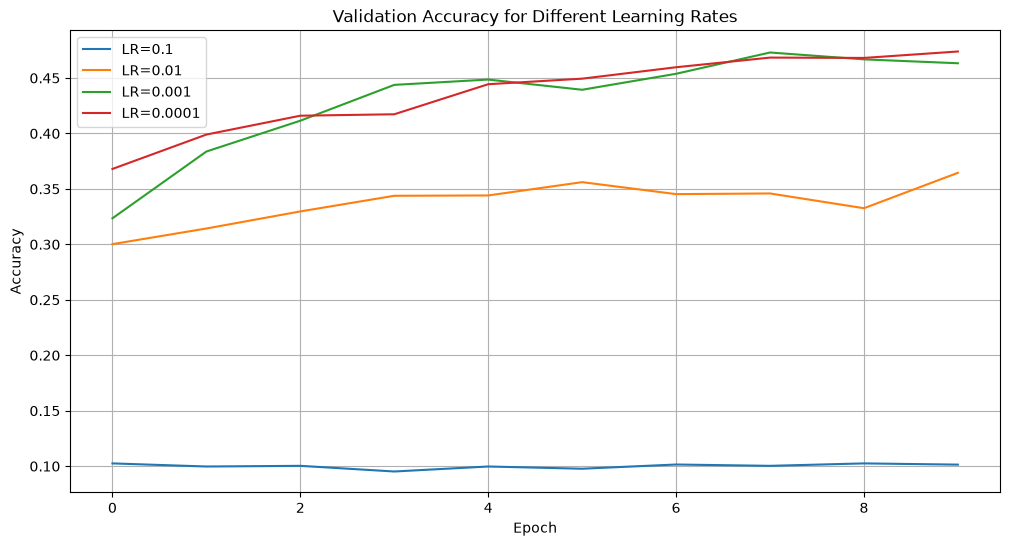

In [15]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs = 10

plt.figure(figsize=(12,6))

for lr in learning_rates:

    history, acc = train_model(learning_rate=lr, epochs=epochs)

    plt.plot(history.history['val_accuracy'],
             label=f"LR={lr}")

plt.title("Validation Accuracy for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3154 - loss: 1.9073 - val_accuracy: 0.3606 - val_loss: 1.7974
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3854 - loss: 1.7079 - val_accuracy: 0.3934 - val_loss: 1.7007
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4191 - loss: 1.6275 - val_accuracy: 0.4194 - val_loss: 1.6442
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4358 - loss: 1.5796 - val_accuracy: 0.4445 - val_loss: 1.5745
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4502 - loss: 1.5358 - val_accuracy: 0.4296 - val_loss: 1.6010

Learning Rate : 0.001
Epochs        : 5
Test Accuracy : 0.4385
Test Loss     : 1.5769
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3187 - loss: 1.8964 - val_accuracy: 0.3477 - val_loss: 1.8019
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3881 - loss: 1.7081 - val_accuracy: 0.4028 - val_loss: 1.6844
Epoch 3/10
625/625 ━━━

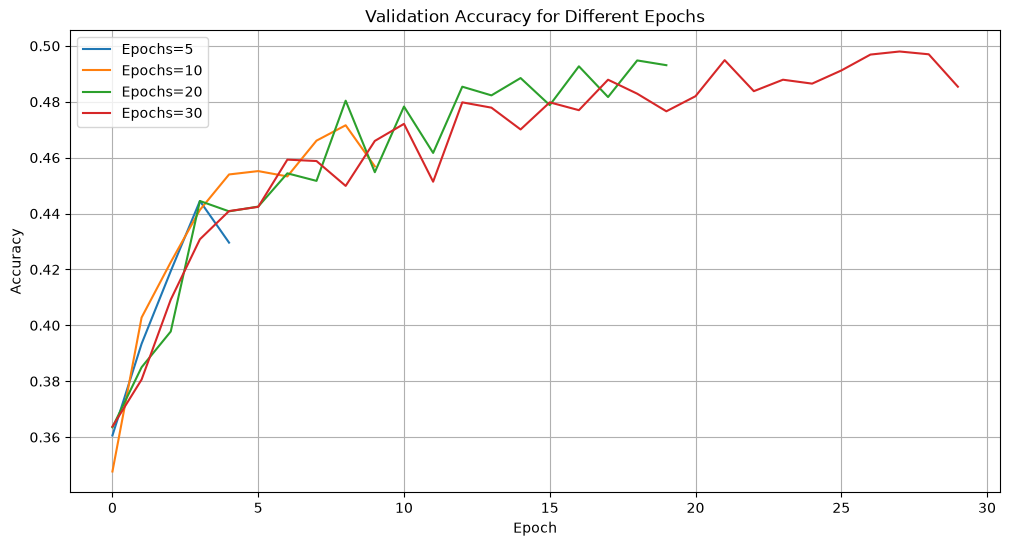

In [16]:
epoch_list = [5,10,20,30]
learning_rate = 0.001

plt.figure(figsize=(12,6))

for ep in epoch_list:

    history, acc = train_model(learning_rate=learning_rate,
                               epochs=ep)

    plt.plot(history.history['val_accuracy'],
             label=f"Epochs={ep}")

plt.title("Validation Accuracy for Different Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()